# Experiment 4: Data Wrangling and Data Visualization

### Nicos Isaiah M. Paz
### 2ECE-C

## A. Visayas Communications DataFrame

In [1]:
import pandas as pd

In [3]:
df = pd.read_excel('board2.xlsx')
df

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [4]:
df['Average']=df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)
VisComm = df.loc[(df['Hometown']=='Visayas')&(df['Track']=='Communication'), ['Name', 'Gender', 'Math', 'Electronics', 'Average']]
VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [5]:
VisComm.shape[0]

5

## B. Visayas Female DataFrame

In [6]:
df['Average']=df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

In [7]:
VisFemale = df.loc[(df['Hometown']=='Visayas')&(df['Gender']=='Female'), ['Name', 'Track', 'GEAS', 'Electronics', 'Average']]
VisFemale

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
10,S11,Communication,48,56,54.75
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
23,S24,Microelectronics,60,45,57.75
25,S26,Instrumentation,83,47,65.75


In [8]:
VisFemale60 = VisFemale.loc[(VisFemale['Average']>=60)]
VisFemale60

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


## C. Category-Average Visualization

In [9]:
df['Average'] = df[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

In [10]:
Track = df.groupby('Track')[['Average']].mean().reset_index()
Track

,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


In [11]:
Gender = df.groupby('Gender')[['Average']].mean().reset_index()
Gender

,Gender,Average
0,Female,66.616667
1,Male,67.183333


In [12]:
Hometown = df.groupby('Hometown')[['Average']].mean().reset_index()
Hometown

,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


In [13]:
import matplotlib.pyplot as plt

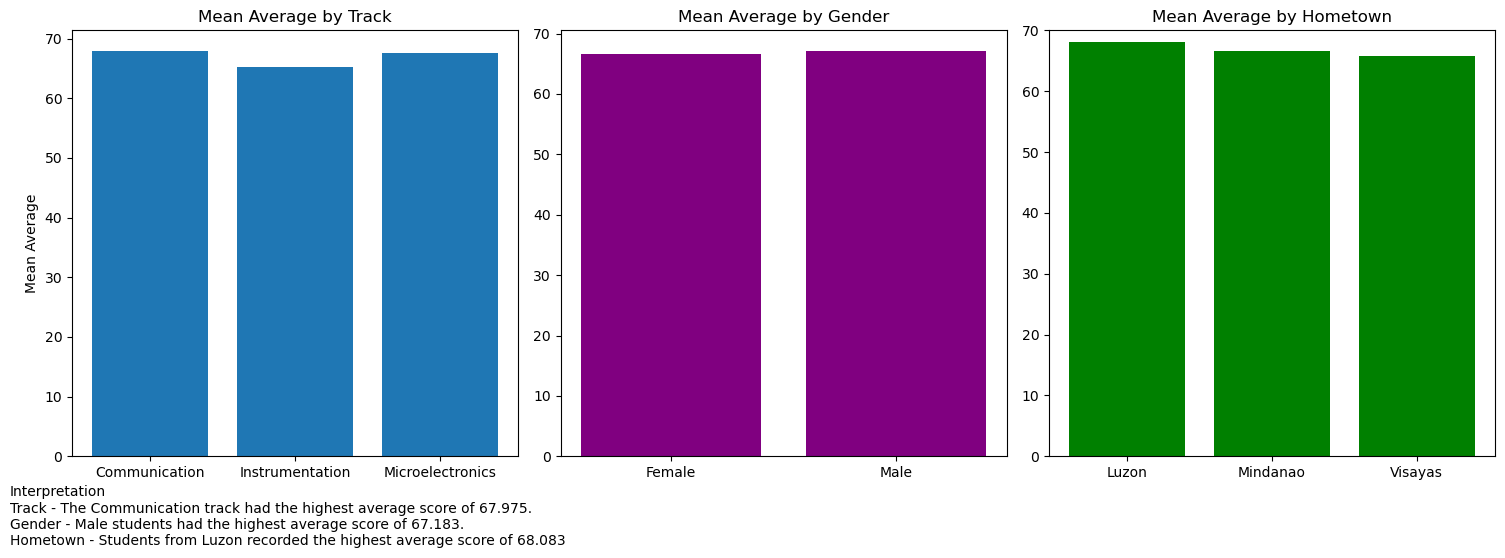

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(Track['Track'], Track['Average'])
axes[0].set_title('Mean Average by Track')
axes[0].set_ylabel('Mean Average')

axes[1].bar(Gender['Gender'], Gender['Average'], color='purple')
axes[1].set_title('Mean Average by Gender')

axes[2].bar(Hometown['Hometown'], Hometown['Average'], color='green')
axes[2].set_title('Mean Average by Hometown')

plt.ylim(0, 70)
plt.tight_layout()
fig.text(0,-0.1,'Interpretation\nTrack - The Communication track had the highest average score of 67.975.\nGender - Male students had the highest average score of 67.183. \nHometown - Students from Luzon recorded the highest average score of 68.083',
         style='normal')
plt.show()